# Lab 9: CTC, Beam Search


**Goal**: This notebook is designed to help you understand the fundamentals of alignment and CTC Decoding.

**Lab workflow**:
- Go to **[Piazza post @621]**.
- Follow the instruction in this notebook and complete the **checkpoints**.
- By the end of the Lab, respond in **[]()** how many checkpoints you completed. It's not graded and designed to help you with your HWs.

**Prepared by**:
- Madhavi, IDL TA S26,  (mgulavan@andrew.cmu.edu)
- Kangping, IDL TA S26,  (kangpinl@andrew.cmu.edu)

**Courtesy of**:
- Last Semester's TAs

**Resources**: This Lab exercise is based on lectures 15 and 16.

##In this lab you will:

1. Learn about the problem of alignment in handwriting recognition.
2. Train a basic model on CTC loss.
3. Run Inference with two CTC techniques: Greedy and Beam decoding.
4. Visualize the resulting alignment.


# Installs

In [1]:
!pip install -q datasets torchinfo torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.3 MB/s eta 0:00:00


# Handwriting Recognition

Transcribe photographs of handwritten text into typed text. A sequence-to-sequence learning problem:

- **Input Space**:  
  $X = (\mathbb{R}^m)^*$, the set of all sequences of $m$-dimensional real-valued vectors.

- **Target Space**:  
  $Z = L^*$, the set of all sequences over a finite character set $L$ of labels.

- **Training Data**:  
  A set $S$ of training examples is drawn from a fixed distribution $D_{X \times Z}$.

- Each example in $S$ consists of a pair of sequences $(x, z)$, where:  
  - $x$ in $X$ is an input sequence.
  - $z$ in $Z$ is the corresponding target sequence.

# Imports

In [2]:
from datasets import load_dataset
import gdown
import random
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import torchvision.transforms.v2 as T
import torch
from torch import nn, optim
from torchvision.models.resnet import BasicBlock
import numpy as np
from torchaudio.models.decoder import cuda_ctc_decoder
import torchmetrics.text as tmt
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
import json
import os
import cv2
from skimage.transform import resize
from PIL import Image
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


# Get IAM-Line Dataset
The IAM Handwriting Database contains forms of handwritten English text which can be used to train and test handwritten text recognizers and to perform writer identification and verification experiments.
- Note that all images are resized to a fixed height of 128 pixels.
- All the documents in the dataset are written in English.

## Data Instances

```python
{
  'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2467x128 at 0x1A800E8E190,
  'text': 'put down a resolution on the subject'
}
```

## Data Fields

- `image`: a `PIL.Image.Image` object containing the image. Note that when accessing the image column (using `dataset[0]["image"]`), the image file is automatically decoded. Decoding of a large number of image files might take a significant amount of time. Thus it is important to first query the sample index before the `image` column, i.e. `dataset[0]["image"]` should always be preferred over dataset["image"][0].
- `text`: the label transcription of the image.


In [3]:
ds = load_dataset("Teklia/IAM-line")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

# Character Encoder

A class for encoding text to indices and decoding indices back to text for handwriting recognition tasks.
    
This class provides functionality to:
1. Create character-to-index and index-to-character mappings
2. Encode text strings to tensor of indices
3. Decode tensor of indices back to text

In [4]:
class CharacterEncoder:
    """
    CharacterEncoder class for encoding text to indices and decoding indices back to text.
    """
    def __init__(self, hf_dataset):
        """
        Initialize the encoder with either text samples or an existing character dictionary.

        Args:
            hf_dataset: the Hugging Face dataset whose samples are used to create the character dictionary
        """
        self.blank_idx = 0
        dataset_splits = ds.keys()
        print(f"Dataset splits: {dataset_splits}")

        # Extract unique characters
        chars = []
        for split in dataset_splits:
            for sample in ds[split]:
                chars.extend(list(sample['text']))
        chars = sorted(list(set(chars)))

        # Create mapping (start from 1 as 0 is reserved for blank)
        self.char_dict = {c:i for i, c in enumerate(chars, 1)}

        # Create inverse mapping
        self.inv_char_dict = {i:c for c, i in self.char_dict.items()}

        # Add Blank Token
        self.char_dict[''] = 0

    def encode(self, text, add_padding=True):
        """
        Convert string to sequence of indices.

        Args:
            text (str): Input text string
        Returns:
            torch.Tensor: Tensor of indices
        """
        return torch.tensor([self.char_dict.get(c, 0) for c in text], dtype=torch.long)

    def decode(self, indices, remove_padding=True):
        """
        Convert sequence of indices to string.

        Args:
            indices (torch.Tensor): Tensor of indices
        Returns:
            str: Decoded text
        """
        return ''.join([self.inv_char_dict.get(idx.item(), '') for idx in indices])

    def __len__(self):
        """Return size of character dictionary."""
        return len(self.char_dict)

    def get_vocab(self):
        """Return list of characters sorted by index."""
        return sorted(self.char_dict.keys(), key=lambda x: self.char_dict[x])

    def print_mapping(self, items_per_row=8):
        """
        Print character-to-index mapping in formatted rows.

        Args:
            items_per_row (int): Number of items to display per row
        """
        print(f"\nCharacter Dictionary (size: {len(self)})")
        print("Character mapping:")
        items = [f"'{k}' → {v:<2}" for k, v in self.char_dict.items()]
        for i in range(0, len(items), items_per_row):
            print("  ".join(items[i:i + items_per_row]))


In [5]:
char_encoder = CharacterEncoder(ds)
char_encoder.print_mapping()

Dataset splits: dict_keys(['train', 'validation', 'test'])

Character Dictionary (size: 80)
Character mapping:
' ' → 1   '!' → 2   '"' → 3   '#' → 4   '&' → 5   ''' → 6   '(' → 7   ')' → 8 
'*' → 9   '+' → 10  ',' → 11  '-' → 12  '.' → 13  '/' → 14  '0' → 15  '1' → 16
'2' → 17  '3' → 18  '4' → 19  '5' → 20  '6' → 21  '7' → 22  '8' → 23  '9' → 24
':' → 25  ';' → 26  '?' → 27  'A' → 28  'B' → 29  'C' → 30  'D' → 31  'E' → 32
'F' → 33  'G' → 34  'H' → 35  'I' → 36  'J' → 37  'K' → 38  'L' → 39  'M' → 40
'N' → 41  'O' → 42  'P' → 43  'Q' → 44  'R' → 45  'S' → 46  'T' → 47  'U' → 48
'V' → 49  'W' → 50  'X' → 51  'Y' → 52  'Z' → 53  'a' → 54  'b' → 55  'c' → 56
'd' → 57  'e' → 58  'f' → 59  'g' → 60  'h' → 61  'i' → 62  'j' → 63  'k' → 64
'l' → 65  'm' → 66  'n' → 67  'o' → 68  'p' → 69  'q' → 70  'r' → 71  's' → 72
't' → 73  'u' → 74  'v' → 75  'w' → 76  'x' → 77  'y' → 78  'z' → 79  '' → 0 


# Dataset

In [6]:
class HandwritingDataset(Dataset):
    """Dataset class for handwriting recognition."""

    def __init__(self, hf_dataset, char_encoder, input_size=(128, None), transform=None, is_training=False):
        """
        Args:
            hf_dataset: Hugging Face dataset
            char_encoder: The character encoder used for encoding text
            input_size (tuple): (height, width) for preprocessing. If width is None, it will be dynamic
            transform (callable, optional): Optional transform to be applied on images
            is_training (bool): Whether this is for training (enables additional augmentation)
        """
        self.dataset = hf_dataset
        self.char_encoder = char_encoder
        self.transform = transform
        self.max_len = max(len(sample['text']) for sample in self.dataset)
        self.input_size = input_size
        self.is_training = is_training
        self.border_size = 8

    def preprocess(self, img):
        """
        Preprocess image to target size while maintaining aspect ratio.

        Args:
            img (numpy.ndarray): Input image array

        Returns:
            numpy.ndarray: Preprocessed image with dimensions matching input_size

        Features:
            1. Training-time augmentation (if is_training=True):
              - Random width scaling: 75% to 125%
              - Random height adjustment: 90% to 110%
            2. Aspect ratio preservation
            3. Border padding
            4. Dynamic width calculation (if width=None)
        """

        h_target, w_target = self.input_size

        if self.is_training:
            # Random scaling during training
            nwidth = int(np.random.uniform(.75, 1.25) * img.shape[1])
            nheight = int((np.random.uniform(.9, 1.1) * img.shape[0] / img.shape[1]) * nwidth)
            img = resize(image=img, output_shape=(nheight, nwidth)).astype(np.float32)

        # Calculate target height
        n_height = min(h_target - 2 * self.border_size, img.shape[0])
        scale = n_height / img.shape[0]

        # Calculate target width
        if w_target is None:
            # Dynamic width based on aspect ratio
            n_width = int(scale * img.shape[1])
            w_target = n_width + 2 * self.border_size
        else:
            n_width = min(w_target - 2 * self.border_size, int(scale * img.shape[1]))

        # Resize image
        img = resize(image=img, output_shape=(n_height, n_width)).astype(np.float32)

        # Pad image
        img = np.pad(
            img,
            ((self.border_size, h_target - n_height - self.border_size),
             (self.border_size, w_target - n_width - self.border_size)),
            mode='median'
        )
        return img

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        """
        Get a single sample from the dataset.

        Args:
            idx (int): Index of the sample

        Returns:
            dict: Contains:
                - 'image': Preprocessed image tensor (C, H, W)
                - 'text': Encoded text tensor
        """

        sample = self.dataset[idx]

        # Get image and convert to numpy if needed
        image = sample['image']
        image = np.array(image)

        # Preprocess image
        image = self.preprocess(image)
        # Convert to PIL Image for torchvision transforms
        image = Image.fromarray(np.uint8(image * 255))  # Convert to uint8 PIL Image

        # Apply additional transforms
        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'text': self.char_encoder.encode(sample['text'])
        }

    def collate_fn(self, batch):
        """
        Creates mini-batch tensors from the list of dictionaries.

        Args:
            batch: list of dictionaries containing:
                - image: torch tensor of shape (1, height, width)
                - text: string of variable length
        Returns:
            images: torch tensor of shape (batch_size, 1, height, width)
            targets: torch tensor of shape (sum(target_lengths))
            lengths: torch tensor of length batch_size
        """
        # Sort batch by width for more efficient packing
        batch = sorted(batch, key=lambda x: x['image'].size(-1), reverse=True)

        # Get max width in batch
        max_width = max(item['image'].size(-1) for item in batch)

        # Pad images to max width
        padded_images = []
        for item in batch:
            img = item['image']
            pad_width = max_width - img.size(-1)
            if pad_width > 0:
                img = F.pad(img, (0, pad_width, 0, 0), value=0)
            padded_images.append(img)

        # Stack images
        images = torch.stack(padded_images, 0)

        # Process words into target indices
        words = [item['text'] for item in batch]
        lengths = torch.tensor([len(word) for word in words])
        targets = torch.cat([word for word in words])

        return images, targets, lengths

## Transforms

In [7]:
train_transforms = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.RandomRotation(2),  # Add random rotation
    T.RandomAffine(degrees=0, shear=(-2, 2)),
    T.ToImage(),  # Convert to torch.Tensor image
    T.ToDtype(torch.float32, scale=True),  # Scale to [0, 1] and convert to float
    T.Normalize(mean=[0.5], std=[0.5])
])

test_transforms = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.ToImage(),  # Convert to torch.Tensor image
    T.ToDtype(torch.float32, scale=True),  # Scale to [0, 1] and convert to float
    T.Normalize(mean=[0.5], std=[0.5])
])

In [8]:
train_dataset = HandwritingDataset(
    hf_dataset   = ds['train'],
    char_encoder = char_encoder,
    input_size   = (128, 1024),
    transform    = train_transforms,
    is_training=True
)

val_dataset = HandwritingDataset(
    hf_dataset = ds['validation'],
    char_encoder = char_encoder,
    input_size = (128, 1024),
    transform  = test_transforms,
    is_training=False
)

test_dataset = HandwritingDataset(
    hf_dataset = ds['test'],
    char_encoder = char_encoder,
    input_size = (128, 1024),
    transform  = test_transforms,
    is_training=False
)

In [9]:
max_len = max(train_dataset.max_len, val_dataset.max_len, test_dataset.max_len)
print(f"Max length: {max_len}")

Max length: 93


# Dataloader

In [10]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    collate_fn = train_dataset.collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False,
    collate_fn = val_dataset.collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False,
    collate_fn = test_dataset.collate_fn
)

# EDA and Viz

In [11]:
def inspect_batch(batch, dataset, max_samples=1):
    """
    Visualize and print detailed information about a batch of data.

    Args:
        batch: tuple of (images, targets, lengths) from dataloader
        dataset: CTCData dataset instance
        max_samples: maximum number of samples to show
    """
    images, targets, lengths = batch
    batch_size = images.shape[0]

    # Print batch information
    print("Batch Information:")
    print(f"Batch size: {batch_size}")
    print(f"\nTensor Shapes:")
    print(f"Images: {images.shape}")
    print(f"Targets: {targets.shape}")
    print(f"Lengths: {lengths.shape}")

    # Print statistics
    print(f"\nImage Statistics:")
    print(f"Min: {images.min():.3f}, Max: {images.max():.3f}")
    print(f"Mean: {images.mean():.3f}, Std: {images.std():.3f}")

    # Show sample decoding
    print(f"\nTarget Encoding/Decoding Examples:")

    # Calculate number of samples to show
    n_samples = min(batch_size, max_samples)

    # Create subplot grid
    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 1.5*n_samples))
    if n_samples == 1:
        axes = [axes]

    # Track current position in targets tensor
    curr_pos = 0

    for idx in range(n_samples):
        # Get current sample
        image = images[idx]
        length = lengths[idx]
        target_indices = targets[curr_pos:curr_pos + length]
        decoded_text = dataset.char_encoder.decode(target_indices)

        # Print encoding/decoding info
        print(f"\nSample {idx}:")
        print(f"Length: {length}")
        print(f"Target indices: {target_indices.tolist()}")
        print(f"Decoded text: '{decoded_text}'")

        # Denormalize image for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = image * std + mean
        img_display = img_display.permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        # Plot image
        axes[idx].imshow(img_display)
        axes[idx].set_title(f"Sample {idx} | Shape: {image.shape}\nText ({length.item()} chars): '{decoded_text}'")
        axes[idx].axis('off')

        # Update position
        curr_pos += length

    plt.tight_layout()
    plt.show()

## The Problem of Alignment

In sequence-to-sequence tasks, we often face the following challenges:

- $|x| \neq |z|$ (Input and target sequence lengths are different).
- $|x| \not\propto |z|$ (No fixed proportional relationship between input and target lengths).
- However, the sequences remain **order-aligned**.

### Training

- Maximize the probability a model assigns to the correct output, for a given input.

- Efficiently computing the conditional probability: $p(z \mid x)$

- The function $p(z \mid x)$ should also be **differentiable**

### Inference  

After training, Find the most likely output sequence $z^*$ given an input $x$: $z^* = \arg\max_z p(z \mid x)$

Batch Information:
Batch size: 16

Tensor Shapes:
Images: torch.Size([16, 1, 128, 1024])
Targets: torch.Size([730])
Lengths: torch.Size([16])

Image Statistics:
Min: -1.000, Max: 1.000
Mean: 0.758, Std: 0.477

Target Encoding/Decoding Examples:

Sample 0:
Length: 57
Target indices: [72, 62, 73, 74, 54, 73, 62, 68, 67, 1, 54, 67, 57, 1, 58, 72, 69, 58, 56, 62, 54, 65, 65, 78, 1, 62, 67, 1, 75, 62, 58, 76, 1, 68, 59, 1, 59, 71, 58, 72, 61, 1, 69, 71, 68, 55, 65, 58, 66, 72, 1, 59, 54, 56, 62, 67, 60]
Decoded text: 'situation and especially in view of fresh problems facing'


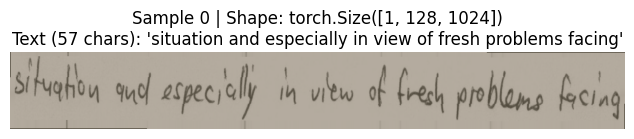

In [12]:
batch = next(iter(train_loader))
inspect_batch(batch, train_dataset)

Batch Information:
Batch size: 16

Tensor Shapes:
Images: torch.Size([16, 1, 128, 1024])
Targets: torch.Size([646])
Lengths: torch.Size([16])

Image Statistics:
Min: -0.961, Max: 1.000
Mean: 0.872, Std: 0.290

Target Encoding/Decoding Examples:

Sample 0:
Length: 39
Target indices: [36, 73, 1, 76, 54, 72, 1, 54, 1, 72, 69, 65, 58, 67, 57, 62, 57, 1, 62, 67, 73, 58, 71, 69, 71, 58, 73, 54, 73, 62, 68, 67, 1, 68, 59, 1, 73, 61, 58]
Decoded text: 'It was a splendid interpretation of the'


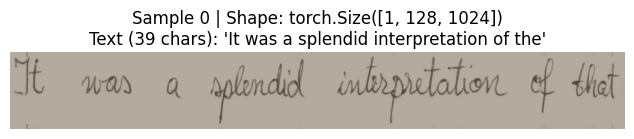

In [13]:
batch = next(iter(val_loader))
inspect_batch(batch, val_dataset)

Batch Information:
Batch size: 16

Tensor Shapes:
Images: torch.Size([16, 1, 128, 1024])
Targets: torch.Size([1044])
Lengths: torch.Size([16])

Image Statistics:
Min: -0.843, Max: 1.000
Mean: 0.853, Std: 0.313

Target Encoding/Decoding Examples:

Sample 0:
Length: 93
Target indices: [54, 72, 72, 74, 71, 58, 57, 67, 58, 72, 72, 1, 3, 1, 29, 58, 65, 65, 54, 1, 29, 58, 65, 65, 54, 1, 40, 54, 71, 62, 58, 1, 3, 1, 7, 1, 43, 54, 71, 65, 68, 69, 61, 68, 67, 58, 1, 8, 1, 11, 1, 54, 1, 65, 62, 75, 58, 65, 78, 1, 72, 68, 67, 60, 1, 73, 61, 54, 73, 1, 56, 61, 54, 67, 60, 58, 72, 1, 73, 58, 66, 69, 68, 1, 66, 62, 57, 12, 76, 54, 78, 1, 13]
Decoded text: 'assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .'


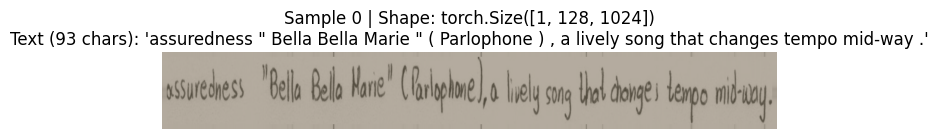

In [14]:
batch = next(iter(test_loader))
inspect_batch(batch, test_dataset)

# Model

- The RNN takes in the input sequence $x$ and maps it to a sequence of network outputs $y$, where each output $y^t$ is a vocab-dimensional vector representing a probability distribution over labels at time $t$.  
- Each probability $y^t_k$ indicates how likely the model thinks label $k$ should be at that timestep.  


Implemented as described in [Best Practices for a Handwritten Text Recognition System](https://arxiv.org/abs/2404.11339)

In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection if dimensions change
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)


class HandwritingRecognizer(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()

        self.config = {
            'num_classes': num_classes,
            'hidden_size': hidden_size
        }

        # CNN Backbone
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # First block: 2x64
            *[ResidualBlock(64, 64) for _ in range(2)],
            nn.MaxPool2d(2, 2),

            # Second block: 3x128
            *[ResidualBlock(64 if i==0 else 128, 128) for i in range(3)],
            nn.MaxPool2d(2, 2),

            # Third block: 2x256
            *[ResidualBlock(128 if i==0 else 256, 256) for i in range(2)]
        )

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=hidden_size,
            num_layers=3,
            bidirectional=True,
            dropout=0.2,
            batch_first=False
        )

        # Output layers
        self.rnn_output = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * 2, num_classes)
        )

        # CNN shortcut branch
        self.cnn_output = nn.Sequential(
            nn.Dropout(0.5),
            nn.Conv2d(256, num_classes, kernel_size=(1, 3), padding=(0, 1))
        )

    def forward(self, x):
        # CNN feature extraction
        features = self.cnn(x)

        # Max pooling along height dimension
        b, c, h, w = features.size()
        features = F.max_pool2d(features, [h, 1])

        # Prepare for LSTM
        features = features.squeeze(2)  # Remove height dimension
        features = features.permute(2, 0, 1)  # (W, B, C)

        # LSTM branch
        lstm_out, _ = self.lstm(features)
        rnn_logits = self.rnn_output(lstm_out)

        # CNN branch
        cnn_logits = self.cnn_output(features.permute(1, 2, 0).unsqueeze(2))
        cnn_logits = cnn_logits.squeeze(2).permute(2, 0, 1)

        if self.training:
            return rnn_logits
        else:
            return rnn_logits

    def get_config(self):
        return self.config

In [17]:
model = HandwritingRecognizer(
    num_classes=len(char_encoder),
    hidden_size=256
)

batch = next(iter(train_loader))
images, targets, lengths = batch
summary(model=model, input_data=[images])

Layer (type:depth-idx)                   Output Shape              Param #
HandwritingRecognizer                    [256, 16, 80]             --
├─Sequential: 1-1                        [16, 256, 32, 256]        --
│    └─Conv2d: 2-1                       [16, 64, 128, 1024]       3,200
│    └─BatchNorm2d: 2-2                  [16, 64, 128, 1024]       128
│    └─ReLU: 2-3                         [16, 64, 128, 1024]       --
│    └─ResidualBlock: 2-4                [16, 64, 128, 1024]       --
│    │    └─Sequential: 3-1              [16, 64, 128, 1024]       --
│    │    └─Conv2d: 3-2                  [16, 64, 128, 1024]       36,928
│    │    └─BatchNorm2d: 3-3             [16, 64, 128, 1024]       128
│    │    └─Conv2d: 3-4                  [16, 64, 128, 1024]       36,928
│    │    └─BatchNorm2d: 3-5             [16, 64, 128, 1024]       128
│    └─ResidualBlock: 2-5                [16, 64, 128, 1024]       --
│    │    └─Sequential: 3-6              [16, 64, 128, 1024]       --
│

## What is CTC (Connectionist Temporal Classification)?
- CTC is a loss function defined for sequence-to-sequence problems.

- An alignment free algorithm!

- The loss function is computed by **summing over all valid alignments** between the input and output sequence using **dynamic programming**.

- CTC uses the forward-backward algorithm, similar to HMMs, to efficiently compute the probability of all alignments.

- Requires the addition of a `blank` token to the label set. To handle cases where:
  - A single label is stretched over multiple timesteps.
  - Some timesteps do not correspond to any label.
  - To distinguish between repeated labels.

# Decoders

## Greedy

Given a sequence of network outputs, where each output is a probability distribution over possible labels at a particular timestep, **greedy search** selects the most likely label at each timestep independently, without considering future steps.

- Checkpoint 1: Get most probable class at each step
- Checkpoint 2: Select a specific batch item
- Checkpoint 3: Remove consecutive duplicates
- Checkpoint 4: Remove blank tokens and convert to list
- `Hint`: You might find [torch.unique_consecutive](https://pytorch.org/docs/stable/generated/torch.unique_consecutive.html) useful

In [18]:
class GreedyDecoder(torch.nn.Module):
    def __init__(self, labels):
        super().__init__()
        self.labels = labels
        self.blank  = 0

    def forward(self, log_probs: torch.Tensor, lengths: torch.Tensor):
        """Given a sequence emission over labels, get the best path
        Args:
          log_probs (Tensor): GPU tensor storing sequences of probability distribution over labels. Shape `[Time x Batch x Num Tokens]`.
          lengths (Tensor): GPU tensor storing the length of each sequence in the batch. Shape `[Batch]`.
                            Unused, present for consistency with `BeamDecoder` interface
        Returns:
          List[List[int]]: The batch of predicted sequence of token IDs.
        """
        batch_size = log_probs.size(1)

        # --------------------------------------
        # Checkpoint 1: Get most probable class at each step
        # --------------------------------------
        indices =  torch.argmax(log_probs, dim=-1)

        decoded_batch = []
        # Process each sequence in the batch
        for b in range(batch_size):
            # --------------------------------------
            # Checkpoint 2: Select a specific batch item
            # --------------------------------------
            sequence =  indices[:, b]
            # --------------------------------------
            # Checkpoint 3: Remove consecutive duplicates
            # --------------------------------------
            sequence = torch.unique_consecutive(sequence)
            # --------------------------------------
            # Checkpoint 4: Remove blank tokens and convert to list
            # --------------------------------------
            sequence = [s.item() for s in sequence if s.item() != self.blank]
            decoded_batch.append(sequence)

        return decoded_batch

## Beam

Given a sequence of network outputs, where each output is a probability distribution over possible labels at a particular timestep, use PyTorch's [CUDACTCecoder](https://pytorch.org/audio/main/generated/torchaudio.models.decoder.CUCTCDecoder.html) to do beam search.

- Checkpoint 5: Prepare input for the decoder
  - What are the expected inputs and input shapes to `self.decoder`?
  - Be sure to make all inputs contiguous with `input.contiguous()`
  - Ensure that lengths are of the right `dtype`
- Checkpoint 6: Extract the best sequence.
  - decoder returns `List[List[CUCTCHypothesis]]` while forward should return `List[List[int]]`
  - You might find the members of a [CUCTCHypothesis](https://pytorch.org/audio/main/generated/torchaudio.models.decoder.CUCTCDecoder.html#torchaudio.models.decoder.CUCTCHypothesis) instance useful.

In [19]:
class BeamDecoder(torch.nn.Module):
    def __init__(self, labels, beam_size=5):
        super().__init__()
        self.decoder = cuda_ctc_decoder(tokens=labels, nbest=1, beam_size=beam_size)

    def forward(self, log_probs: torch.Tensor, lengths: torch.Tensor):
        """
        Given a sequence emission over labels, get the best path
        Args:
          log_probs (Tensor): GPU tensor storing sequences of probability distribution over labels. Shape `[Time x Batch x Num Tokens]`.
          lengths (Tensor): GPU tensor storing the length of each sequence in the batch. Shape `[Batch]`.
        Returns:
          List[List[int]]: The batch of predicted sequence of token IDs.
        """
        # --------------------------------------
        # Checkpoint 5: Prepare input for the decoder
        # --------------------------------------
        decoded = self.decoder(log_probs.transpose(0,1).contiguous())

        # --------------------------------------
        # Checkpoint 6: Extract the best sequence
        # --------------------------------------
        decoded_batch = [x[0].tokens for x in decoded]
        return decoded_batch

# Pipeline

Trainer Class:
- Checkpoint 7: Fixed-size inputs for CTC
  - CTC loss requires knowing the length of each input sequence.  
  - Since images have **variable widths**, we must define the number of **time steps** per batch item.
- **Hint:**  
  - `input_lengths` should be set to the **time dimension** of `log_probs`.

- Checkpoint 8: Calculate CTC loss
  - What arguments does `nn.CTCLoss` require?
- Checkpoint 9: Decode predictions to character indices
  - **Which decoding method should we use?**
    - **Greedy decoding (`argmax`)** is fast but inaccurate.  
    - **Beam search (`BeamDecoder`)** improves accuracy by considering multiple sequences.
  - **Hint:**  
    - Initialize and use `self.decoder()`.

In [21]:
class Trainer:
    """
    Trainer class for handwriting recognition model.

    Handles:
    - Training loop with mixed precision
    - Model evaluation
    - Metrics calculation (CER, WER, Edit Distance)
    - Checkpointing
    - Prediction logging
    """
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda', save_dir='predictions', save_every=5):
        """
        Initialize trainer.
        Be sure to initializer optimizer, scheduler and decoder before calling train():
        Eg:
            trainer.optimizer = optim.AdamW(trainer.model.parameters(), lr=1e-3, weight_decay=1e-4)
            trainer.scheduler = optim.lr_scheduler.CosineAnnealingLR(trainer.optimizer, T_max=800, eta_min=1e-6)
            trainer.decoder   = BeamDecoder(labels=char_encoder.get_vocab(), beam_size=5)

        Args:
            model: Neural network model
            train_loader: DataLoader for training data
            val_loader: DataLoader for validation data
            test_loader: DataLoader for test data
            device: Device to run on ('cuda' or 'cpu')
            save_dir: Directory to save checkpoints and predictions
            save_every: Save predictions every N epochs
        """
        # Model and data
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.test_loader  = test_loader
        self.char_encoder = train_loader.dataset.char_encoder
        self.device  = device

        # Loss and optimization
        self.criterion = nn.CTCLoss(blank=0, zero_infinity=True, reduction='mean')
        self.optimizer = None
        self.scheduler = None
        self.decoder   = None
        self.scaler    = torch.amp.GradScaler(device = 'cuda')

        # Initialize metrics
        self.wer_metric       = tmt.WordErrorRate()
        self.word_edit_metric = tmt.EditDistance(reduction='mean')
        self.cer_metric       = tmt.CharErrorRate()

        # Saving parameters
        self.save_dir         = save_dir
        self.save_every       = save_every
        os.makedirs(save_dir, exist_ok=True)

    def train_epoch(self):
        """
        Train model for one epoch.

        Returns:
            float: Average loss for the epoch
        """
        self.model.train()
        total_loss = 0

        # Setup progress bar
        current_lr = self.optimizer.param_groups[0]['lr']
        batch_bar = tqdm(total=len(self.train_loader), dynamic_ncols=True, leave=False, position=0, desc=f"Training (lr: {current_lr:.6f})")

        for i, batch in enumerate(self.train_loader):

            # Move batch to device and unpack
            images, targets, target_lengths = [x.to(self.device) for x in batch]
            batch_size = images.size(0)

            # Mixed precision training
            with torch.amp.autocast(device_type = 'cuda'):
                # Forward pass: (B, C, H, W) -> (T, B, V)
                log_probs = self.model(images).log_softmax(2)

                # --------------------------------------
                # Checkpoint 7: Fixed-size inputs for CTC
                # --------------------------------------
                input_lengths = torch.full((batch_size,), log_probs.size(0), dtype=torch.long, device=device)

                # --------------------------------------
                # Checkpoint 8: Calculate CTC loss
                # --------------------------------------
                loss = self.criterion(log_probs, targets, input_lengths, target_lengths)

            # Backward pass with gradient scaling
            self.optimizer.zero_grad()
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            # Update metrics
            total_loss += loss.item()
            avg_loss = total_loss / (i + 1)

            # Update progress bar
            batch_bar.set_postfix(loss=f"{avg_loss:.4f}")
            batch_bar.update()

        batch_bar.close()
        self.scheduler.step()
        return total_loss / len(self.train_loader)

    @torch.no_grad()
    def evaluate(self):
        """
        Evaluate model on validation set.

        Returns:
            dict: Contains:
                - metrics: Dict of averaged metrics
                - predictions: List of detailed prediction information
        """
        self.model.eval()
        total_cer   = 0
        total_wer   = 0
        total_dist  = 0
        num_samples = 0

        # Store predictions if epoch is provided
        predictions = []
        for batch_idx, batch in enumerate(tqdm(self.val_loader, desc='Evaluating')):

            # Move batch to device and unpack
            images, targets, target_lengths = [x.to(self.device) for x in batch]
            batch_size = images.size(0)

            # Forward pass: (B, C, H, W) -> (T, B, V)
            log_probs = self.model(images).log_softmax(2)
            input_lengths = torch.full((batch_size,), log_probs.size(0), device=self.device)

            # --------------------------------------
            # Checkpoint 9: Decode predictions to character indices
            # --------------------------------------
            decoded = self.decoder(log_probs, input_lengths)

            # Calculate metrics for each sample
            for i in range(batch_size):

                # Get individual predictions and targets
                pred = torch.tensor(decoded[i], device=trainer.device)
                target = targets[sum(target_lengths[:i]):sum(target_lengths[:i+1])]

                # Convert indices to text
                pred_text   = self.char_encoder.decode(pred)
                target_text = self.char_encoder.decode(target)

                # Calculate metrics
                dist = self.word_edit_metric(pred_text, target_text)
                wer  = self.wer_metric(pred_text, target_text)
                cer  = self.cer_metric(pred_text, target_text)

                # Update running totals
                total_dist += dist
                total_wer  += wer
                total_cer  += cer

                # Store detailed prediction information
                predictions.append({
                    'idx': batch_size * batch_idx + i,
                    'prediction': pred_text,
                    'target': target_text,
                    'edit_distance': dist.item(),
                    'wer': wer.item(),
                    'cer': cer.item()
                })

            num_samples += batch_size

        # Return metrics and predictions
        return {
            'metrics': {
                'Edit Distance': total_dist.item() / num_samples,
                'CER': total_cer.item() * 100 / num_samples,
                'WER': total_wer.item() * 100 / num_samples
            },
            'predictions': predictions
        }

    def train(self, epochs):
        """
        Train model for multiple epochs.

        Args:
            epochs (int): Number of epochs to train
        """
        if self.optimizer is None or self.scheduler is None or self.decoder is None:
            raise ValueError("Optimizer, scheduler, and decoder must be set before training.")

        best_cer = float('inf')

        for epoch in range(epochs):
            # Training phase
            train_loss = self.train_epoch()

            # Evaluation phase
            pred_dict = self.evaluate()
            metrics = pred_dict['metrics']

            # Save predictions periodically
            if (epoch + 1) % self.save_every == 0:
              save_path = os.path.join(self.save_dir, f'predictions_epoch_{epoch+1}.json')
              with open(save_path, 'w', encoding='utf-8') as f:
                  json.dump(pred_dict, f, indent=2, ensure_ascii=False)

            # Save best model based on CER
            if metrics['CER'] < best_cer:
                best_cer = metrics['CER']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'scheduler_state_dict': self.scheduler.state_dict(),
                    'best_cer': best_cer,
                    'metrics': metrics,
                    'config': self.model.get_config()
                }, os.path.join(self.save_dir, 'best_model.pt'))

            # Log epoch metrics
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"Train Loss    : {train_loss:.4f}")
            print(f"Edit Distance : {metrics['Edit Distance']:.4f}")
            print(f"CER           : {metrics['CER']:.4f}")
            print(f"WER           : {metrics['WER']:.4f}")
            print("-" * 50)

    def load_checkpoint(self, checkpoint_path):
      """
      Load a checkpoint from a file.

      Args:
          checkpoint_path (str): Path to the checkpoint file
      """
      try:
        checkpoint = torch.load(checkpoint_path, map_location=self.device, weights_only=True)

        # Load model weights
        self.model.load_state_dict(checkpoint['model_state_dict'])

        # Load optimizer state if provided
        if self.optimizer is not None and 'optimizer_state_dict' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        # Load scheduler state if provided
        if self.scheduler is not None and 'scheduler_state_dict' in checkpoint:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        # Print checkpoint info

        # Header
        print("\n📊 Checkpoint Information")
        print("========================")

        # Basic Info
        print(f"📅 Epoch: {checkpoint['epoch']}")
        print(f"🎯 Best CER: {checkpoint['best_cer']:.2f}%")

        # Metrics
        print("\n📈 Metrics")
        print("---------")
        metrics = checkpoint['metrics']
        print(f"Edit Distance : {metrics['Edit Distance']:.4f}")
        print(f"CER           : {metrics['CER']:.2f}%")
        print(f"WER           : {metrics['WER']:.2f}%")

        # Model Configuration
        print("\n🔧 Model Configuration")
        print("-------------------")
        config = checkpoint['config']
        for key, value in config.items():
            if isinstance(value, (int, float, str, bool)):
                print(f"{key}: {value}")
            elif isinstance(value, (list, tuple)):
                print(f"{key}: {', '.join(map(str, value))}")
            elif isinstance(value, dict):
                print(f"{key}:")
                for k, v in value.items():
                    print(f"  {k}: {v}")

        # Model Size
        model_size = sum(p.numel() for p in checkpoint['model_state_dict'].values())
        print(f"\n📦 Model Size: {model_size:,} parameters")

        # File Info
        file_size = os.path.getsize(checkpoint_path) / (1024 * 1024)  # MB
        print(f"💾 Checkpoint Size: {file_size:.1f}MB")
        print(f"📍 Location: {os.path.abspath(checkpoint_path)}")

      except Exception as e:
          print(f"❌ Error loading checkpoint: {str(e)}")
          return None

# Experiments!

In [22]:
!gdown 1--Qk2f4ebxXP5gbCbxc24anREL6XgDfE --output chkpt_lab_9.pt

Downloading...
From (original): https://drive.google.com/uc?id=1--Qk2f4ebxXP5gbCbxc24anREL6XgDfE
From (redirected): https://drive.google.com/uc?id=1--Qk2f4ebxXP5gbCbxc24anREL6XgDfE&confirm=t&uuid=c306f0c3-3ea9-4b0a-bd22-f31427dc9a87
To: /content/chkpt_lab_9.pt
100% 88.3M/88.3M [00:04<00:00, 18.8MB/s]


In [23]:
trainer   = Trainer(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    test_loader  = test_loader,
    device       = device,
    save_dir     = 'experiments/run1',
    save_every   = 5
)

In [24]:
trainer.load_checkpoint('chkpt_lab_9.pt')


📊 Checkpoint Information
📅 Epoch: 90
🎯 Best CER: 4.95%

📈 Metrics
---------
Edit Distance : 2.0584
CER           : 4.95%
WER           : 17.86%

🔧 Model Configuration
-------------------
num_classes: 80
hidden_size: 256

📦 Model Size: 7,388,593 parameters
💾 Checkpoint Size: 84.2MB
📍 Location: /content/chkpt_lab_9.pt


In [25]:
trainer.optimizer = optim.AdamW(trainer.model.parameters(), lr=1e-4, weight_decay=1e-4)
trainer.scheduler = optim.lr_scheduler.CosineAnnealingLR(trainer.optimizer, T_max=1, eta_min=1e-6)

In [ ]:
trainer.decoder   = GreedyDecoder(labels=char_encoder.get_vocab())
trainer.train(epochs=1)

Training (lr: 0.000100):   0%|          | 0/406 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/61 [00:00<?, ?it/s]

Epoch 1/1
Train Loss    : 0.0165
Edit Distance : 2.0041
CER           : 4.8570
WER           : 17.4247
--------------------------------------------------


In [ ]:
trainer.decoder   = BeamDecoder(labels=char_encoder.get_vocab(), beam_size=5)
trainer.train(epochs=1)

Training (lr: 0.000001):   0%|          | 0/406 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/61 [00:00<?, ?it/s]

TypeError: CUCTCDecoder.__call__() missing 1 required positional argument: 'encoder_out_lens'

# Inference


- Checkpoint 10: Forward pass and decode predictions
  - **What happens in the forward pass?**
    - The model converts an **image into a sequence of character probabilities**.
    - We apply **log softmax** before decoding.
  - **How do we compute performance metrics?**
    - Compare the predicted text with the ground truth using:
      - **Edit Distance** (How many changes are needed?)
      - **CER** (Character Error Rate)
      - **WER** (Word Error Rate)
  - **Hint:**  
    - Ensure `input_lengths` matches `log_probs.size(0)`.

In [ ]:
# Get a batch from test_loader
batch = next(iter(test_loader))
images, targets, target_lengths = batch
trainer.decoder = BeamDecoder(labels=char_encoder.get_vocab(), beam_size=5)

# Get random indices
rand_idx = random.randint(0, len(batch))
image = images[rand_idx].unsqueeze(0).to(trainer.device)
target = targets[sum(target_lengths[:rand_idx]):sum(target_lengths[:rand_idx+1])].to(trainer.device)


# --------------------------------------
# Checkpoint 10: Forward pass and decode predictions
# --------------------------------------
emission = trainer.model(image)
log_probs = emission.log_softmax(2)
input_lengths = torch.full((1,), log_probs.size(0), device=trainer.device)
decoded = trainer.decoder(log_probs, input_lengths)
pred = torch.tensor(decoded[0], device=trainer.device)

# Convert to text
pred_text = char_encoder.decode(pred)
target_text = char_encoder.decode(target)

# Calculate metrics
dist = trainer.word_edit_metric(pred_text, target_text)
wer = trainer.wer_metric(pred_text, target_text) * 100
cer = trainer.cer_metric(pred_text, target_text) * 100

# Print results
print("-" * 50)
print(f"Prediction    : {pred_text}")
print(f"Target        : {target_text}")
print(f"Edit Distance : {dist:.4f}")
print(f"CER           : {cer:.4f}")
print(f"WER           : {wer:.4f}")
print("-" * 50)

After implementing all checkpoints:
- **Run the pipeline** and compare performance using **different beam sizes**.
- **Analyze the CER/WER** to understand how well the model is performing.

# Alignment Viz

We will use our model's outputs to do `Forced Alignment`, where we try to align a transcript with it's corresponding image by determining the precise timing of each character or word within the image.

Use Pytorch's [`forced_align()`](https://pytorch.org/audio/main/tutorials/ctc_forced_alignment_api_tutorial.html) to visualize the alignment learned by the model.

- `forced_align()` takes emission and token sequences and outputs timestaps of the tokens and their scores.

- Emission reperesents the frame-wise probability distribution over tokens, and it can be obtained by passing waveform to an acoustic model.

- Tokens are numerical expression of transcripts.

- Can help you access:
  -  How closely the model's output match the actual transcript at each point in time.
  - The probability values in the emissions reflect the model's confidence in its predictions at each frame.

In [ ]:
import torchaudio.functional as aF
import re

def unflatten(list_, lengths):
    assert len(list_) == sum(lengths)
    i = 0
    ret = []
    for l in lengths:
        ret.append(list_[i : i + l])
        i += l
    return ret

# Prepare Data
image      = image.squeeze().cpu()  # (H, W)
target_seq = char_encoder.encode(target_text)
LABELS     = char_encoder.get_vocab()

# Create figure
fig, (ax1, ax_mid, ax2) = plt.subplots(3, 1, figsize=(12,6),
                                          gridspec_kw={'height_ratios': [1.5, 0.3, 1]})

# 1. Plot probability heatmap
im = ax1.imshow(log_probs[:, 0].detach().cpu().T, aspect='auto')
ax1.set_title("Character Probabilities Over Width")
ax1.set_xlabel("Position")
ax1.set_ylabel("Characters")

# Middle axis for annotations
ax_mid.set_xlim(ax1.get_xlim())
ax_mid.set_xticks([])
ax_mid.set_yticks([])

# 2. Plot input image
ax2.imshow(image, cmap='gray', aspect='auto')
ax2.set_title("Input Image")

# Encode target sequence
target_seq = char_encoder.encode(target_text)

# Get CTC alignment
alignment, scores = aF.forced_align(
    log_probs.transpose(0, 1).cpu(),
    target_seq.unsqueeze(0),
    blank=0
)
aligned_tokens, alignment_scores = alignment[0], scores[0].exp()

# Get token spans
token_spans = aF.merge_tokens(aligned_tokens, alignment_scores)

# Split text into words
words = re.findall(r'\S+|\s+', target_text)

# Get word spans
word_spans = unflatten(token_spans, [len(word) for word in words])

# Calculate width ratio between image and logits
width_ratio = image.shape[1] / log_probs.shape[0]

# Plot alignments
for spans, word in zip(word_spans, words):
        if len(spans) == 0:
            continue

        # Get start and end positions (word)
        start_pos = spans[0].start
        end_pos = spans[-1].end
        mid_pos = (start_pos + end_pos) / 2

        # Add vertical spans
        ax1.axvspan(start_pos, end_pos, facecolor="None",
                   hatch="/", edgecolor="white", alpha=0.7)
        ax2.axvspan(start_pos * width_ratio, end_pos * width_ratio,
                   facecolor="None", hatch="/", edgecolor="black", alpha=0.3)

        # Add character annotations in middle
        for span, char in zip(spans, word):
            ax_mid.annotate(char,
                          (span.start, 0.5),
                          ha='center',
                          va='center',
                          fontsize=15.0)

plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.95, hspace=0.3)